# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/covid_19_clean_complete.csv")

In [6]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
global_data = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

global_data.head()

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,555,17,28,510
1,2020-01-23,654,18,30,606
2,2020-01-24,941,26,36,879
3,2020-01-25,1434,42,39,1353
4,2020-01-26,2118,56,52,2010


In [11]:
global_data.shape

(188, 5)

In [12]:
import plotly
print(plotly.__version__)

5.24.1


In [13]:
pip install plotly

In [14]:
import plotly.express as px

fig = px.line(global_data,x='Date',y='Confirmed',title='Global Confirmed Cases Trend')

fig.show()

In [15]:
fig = px.line(global_data,x='Date',y='Deaths',title='Global Death Cases Trend')

fig.show()

In [16]:
fig = px.line(global_data,x='Date',y='Recovered',title='Global Recovery Trend')

fig.show()

In [17]:
fig = px.line(global_data,x='Date',y='Active',title='Global Active Cases Trend')

fig.show()

In [18]:
global_data['Recovery Rate'] = (global_data['Recovered']/global_data['Confirmed']) * 100

In [27]:
global_data

,Date,Confirmed,Deaths,Recovered,Active,Recovery Rate
0,2020-01-22,555,17,28,510,5.045045
1,2020-01-23,654,18,30,606,4.587156
2,2020-01-24,941,26,36,879,3.825717
3,2020-01-25,1434,42,39,1353,2.719665
4,2020-01-26,2118,56,52,2010,2.455146
...,...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006,56.161824
184,2020-07-24,15791645,639650,8939705,6212290,56.610347
185,2020-07-25,16047190,644517,9158743,6243930,57.073812
186,2020-07-26,16251796,648621,9293464,6309711,57.184228


In [19]:
fig = px.line(global_data,x='Date',y='Recovery Rate',title='Recovery Rate Trend')

fig.show()

In [20]:
pip install prophet

In [21]:
from prophet import Prophet

prophet_df = global_data[['Date', 'Confirmed']]

prophet_df.columns = ['ds','y']

In [22]:
model = Prophet()

model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [23]:
future = model.make_future_dataframe(periods=7)

forecast = model.predict(future)

In [24]:
forecast[['ds', 'yhat']].tail(7)

,ds,yhat
188,2020-07-28,1.632021e+07
189,2020-07-29,1.652998e+07
190,2020-07-30,1.674392e+07
191,2020-07-31,1.695911e+07
192,2020-08-01,1.716677e+07
193,2020-08-02,1.736430e+07
194,2020-08-03,1.755889e+07


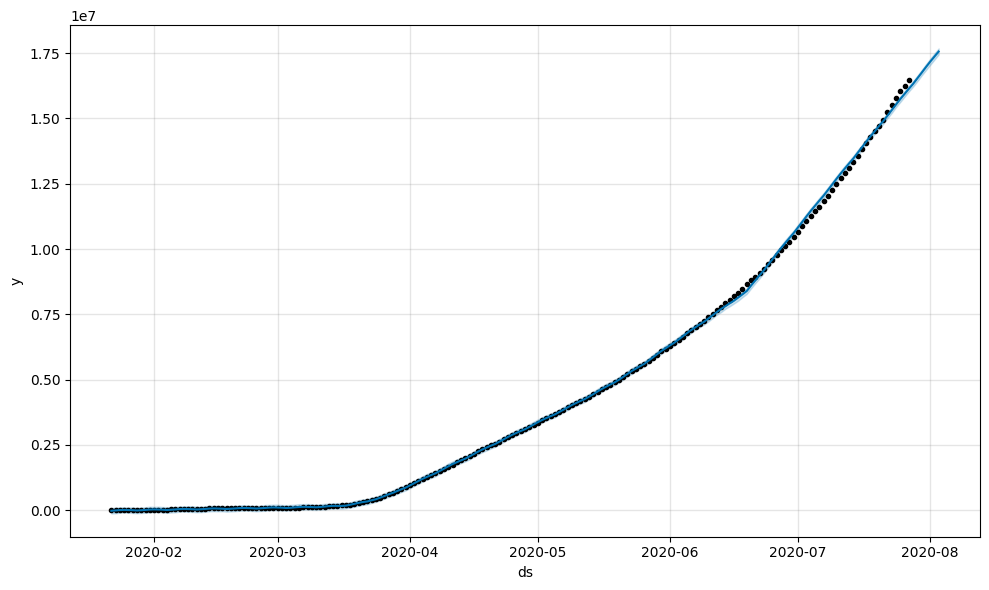

In [25]:
fig = model.plot(forecast)

# Conclusion:
# The forecast indicates that COVID-19 cases increased steadily over the observed period and are expected to continue rising in the coming week.